# ECOv003 JET Accuracy Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data. 

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the JET ensemble, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from verma_net_radiation import verma_net_radiation_table
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Configuration Options

Set configuration options for the notebook, including whether to save plots to files.

In [3]:
# Configuration: Set to True to save plots to files, False to only display them
SAVE_PLOTS = False

In [4]:
input_variables = [
    "ST_C",
    "NDVI",
    "albedo",
    "Ta_C",
    "RH",
    "AOT",
    "COT",
    "vapor_gccm",
    "ozone_cm",
    "elevation_m",
    "canopy_height_meters"
]

output_variables = [
    "Rn_Wm2",
    "ET_daylight_kg",
    "GPP_inst_g_m2_s"
]

# Per-variable physical bounds to keep perturbations realistic
input_min = {
    "ST_C": 0.0,
    "NDVI": 0.05,
    "albedo": 0.0,
    "Ta_C": 0.0,
    "RH": 0.0,
    "AOT": 0.0,
    "COT": 0.0,
    "vapor_gccm": 0.0,
    "ozone_cm": 0.0,
    "elevation_m": 0.0,
    "canopy_height_meters": 0.0,
}

input_max = {
    "ST_C": 50.0,
    "NDVI": 1,
    "albedo": 1,
}

## Define Processing Function for Model Table

This cell defines the forward process for analysis as the BESS-JPL model.

In [5]:
forward_process = process_JET_table
model_name = "JET"

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out surface temperatures greater than 50 Celsius and NDVI values less than 0.05. The resulting DataFrame is displayed for inspection.

In [6]:
input_df = load_ECOv002_calval_JET_inputs()

# Apply lower and upper bounds from configuration dictionaries
mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask]
input_df = input_df.dropna()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,CL,Tmin_open,Tmin_closed,VPD_open,VPD_closed,Tmin_C,Topt_C,fAPARmax,field_capacity,wilting_point
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,2.58,0.4060,0.32,0.14
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,8.48,0.4017,0.29,0.12


## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the model, and displays the resulting DataFrame.

In [7]:
processed = forward_process(input_df)
processed

[2026-08-09 19:47:18 INFO] starting JET table processing
[2026-08-09 19:47:18 INFO] started extracting geometry from JET input table
[2026-08-09 19:47:18 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-09 19:47:18 INFO] started extracting time from JET input table
[2026-08-09 19:47:18 INFO] completed extracting time from JET input table (0.003 seconds)
[2026-08-09 19:47:18 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[2026-08-09 19:47:18 INFO] completed processing FLiES-ANN in 0.32 seconds
[2026-08-09 19:47:18 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-09 19:47:18 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-09 19:47:18 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-09 19:47:18 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)
[2026-08-09 19:4

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,24.219544,24.219544,203.764376,203.764376,248.713696,2.900053,0.510811,0.000151,0.000058,2.606544
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,13.772918,13.772918,163.144742,163.144742,194.438550,2.854526,1.085331,0.000108,0.000034,3.174119
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,33.327171,33.327171,342.565013,342.565013,348.501129,4.442026,0.971980,0.000291,0.000122,2.390822
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,42.878466,42.878466,403.011097,403.011097,366.186555,4.947329,1.401781,0.000294,0.000211,1.388074
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,2.903705,2.903705,112.556235,112.556235,52.720986,2.991218,0.730132,0.000095,0.000015,6.238326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,29.623891,29.623891,397.732265,397.732265,216.894638,3.642505,1.045928,0.000233,0.000137,1.697664
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,21.577865,21.577865,285.469147,285.469147,216.864039,2.883329,1.141584,0.000138,0.000101,1.357232
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,77.061858,77.061858,105.892160,105.892160,409.322436,1.323772,1.130343,0.000053,0.000016,3.203371
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,69.968594,69.968594,119.836612,119.836612,285.958690,1.413853,1.294936,0.000048,0.000031,1.555148


## Accuracy Comparison of In-Situ Observations to Model Estimates

Examining the accuracy of model estimates compared to ground data.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

def generate_accuracy_plot(df, x_variable, y_variable, output_variable, model_name, color_col='ST_C', cbar_label="ECOSTRESS Surface Temperature (°C)", save_plots=False):
    """
    Generates and optionally saves a scatter plot comparing in-situ data to model output,
    including a 1:1 line, OLS regression fit, R-squared, and RMSE annotations.
    """
    # FIX 3: Replaced hardcoded 'ST_C' with color_col parameter
    valid_data = df[[x_variable, y_variable, color_col]].dropna()
    
    # Create the scatter plot
    # FIX: Removed `color=None` to prevent conflicts with `c` in newer matplotlib versions
    sc = plt.scatter(
        x=valid_data[x_variable],
        y=valid_data[y_variable],
        c=valid_data[color_col],
        cmap="jet",
        s=5
    )

    # Get the actual data bounds to ensure lines span the whole plot
    x_min, x_max = valid_data[x_variable].min(), valid_data[x_variable].max()
    y_min, y_max = valid_data[y_variable].min(), valid_data[y_variable].max()
    
    # Calculate a square bounding box for the 1:1 line
    plot_min = min(x_min, y_min)
    plot_max = max(x_max, y_max)

    # FIX 2: Draw 1-to-1 line across the entire data range, not just 5th-95th percentile
    plt.plot([plot_min, plot_max], [plot_min, plot_max], color='black', linestyle='-', linewidth=1, label='1:1 Line')

    # Add OLS regression line
    coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
    ols_x = np.array([x_min, x_max])
    ols_y = coefs[0] * ols_x + coefs[1]
    plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

    # FIX 1: Calculate metrics properly
    # R-squared of the linear fit (how linear the relationship is)
    y_true_for_r2 = valid_data[y_variable]
    y_pred_from_ols = coefs[0] * valid_data[x_variable] + coefs[1]
    r2 = r2_score(y_true_for_r2, y_pred_from_ols)
    
    # RMSE between the model and in-situ data (how accurate the model actually is)
    rmse = np.sqrt(mean_squared_error(valid_data[x_variable], valid_data[y_variable]))

    # Annotate R-squared and RMSE on plot in lower left corner
    plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}",
                xy=(0.05, 0.05), xycoords='axes fraction',
                ha='left', va='bottom',
                fontsize=10,
                bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

    # Format the plot
    plt.grid(True, zorder=0) 
    plt.xlabel(f"In-Situ {output_variable}")
    plt.ylabel(f"{model_name} {output_variable}")
    plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
    
    # FIX 3: Use dynamic colorbar label
    plt.colorbar(sc, label=cbar_label)
    plt.legend(loc='upper right')
    
    # Save if requested
    if save_plots:
        plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
        plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
    
    plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

def generate_accuracy_plot(df, x_variable, y_variable, output_variable, model_name, color_col='ST_C', cbar_label="ECOSTRESS Surface Temperature (°C)", save_plots=False):
    """
    Generates and optionally saves a scatter plot comparing in-situ data to model output,
    including a 1:1 line, OLS regression fit, R-squared, and RMSE annotations.
    """
    # FIX 3: Replaced hardcoded 'ST_C' with color_col parameter
    valid_data = df[[x_variable, y_variable, color_col]].dropna()
    
    # Create the scatter plot
    # FIX: Removed `color=None` to prevent conflicts with `c` in newer matplotlib versions
    sc = plt.scatter(
        x=valid_data[x_variable],
        y=valid_data[y_variable],
        c=valid_data[color_col],
        cmap="jet",
        s=5
    )

    # Get the actual data bounds to ensure lines span the whole plot
    x_min, x_max = valid_data[x_variable].min(), valid_data[x_variable].max()
    y_min, y_max = valid_data[y_variable].min(), valid_data[y_variable].max()
    
    # Calculate a square bounding box for the 1:1 line
    plot_min = min(x_min, y_min)
    plot_max = max(x_max, y_max)

    # FIX 2: Draw 1-to-1 line across the entire data range, not just 5th-95th percentile
    plt.plot([plot_min, plot_max], [plot_min, plot_max], color='black', linestyle='-', linewidth=1, label='1:1 Line')

    # Add OLS regression line
    coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
    ols_x = np.array([x_min, x_max])
    ols_y = coefs[0] * ols_x + coefs[1]
    plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

    # FIX 1: Calculate metrics properly
    # R-squared of the linear fit (how linear the relationship is)
    y_true_for_r2 = valid_data[y_variable]
    y_pred_from_ols = coefs[0] * valid_data[x_variable] + coefs[1]
    r2 = r2_score(y_true_for_r2, y_pred_from_ols)
    
    # RMSE between the model and in-situ data (how accurate the model actually is)
    rmse = np.sqrt(mean_squared_error(valid_data[x_variable], valid_data[y_variable]))

    # Annotate R-squared and RMSE on plot in lower right corner
    plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}",
                xy=(0.95, 0.05), xycoords='axes fraction',  # Changed x-coordinate to 0.95
                ha='right', va='bottom',                    # Changed horizontal alignment to 'right'
                fontsize=10,
                bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

    # Format the plot
    plt.grid(True, zorder=0) 
    plt.xlabel(f"In-Situ {output_variable}")
    plt.ylabel(f"{model_name} {output_variable}")
    plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
    
    # FIX 3: Use dynamic colorbar label
    plt.colorbar(sc, label=cbar_label)
    
    # Place the line legend in the top-left
    plt.legend(loc='upper left')
    
    # Save if requested
    if save_plots:
        plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
        plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
    
    plt.show()

analyzing JET accuracy for ET_daylight_kg compared to insitu_ET_daylight_kg


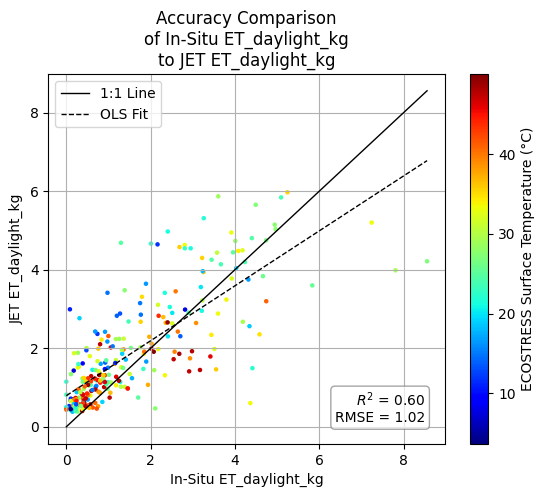

analyzing JET accuracy for G_Wm2 compared to insitu_G_Wm2


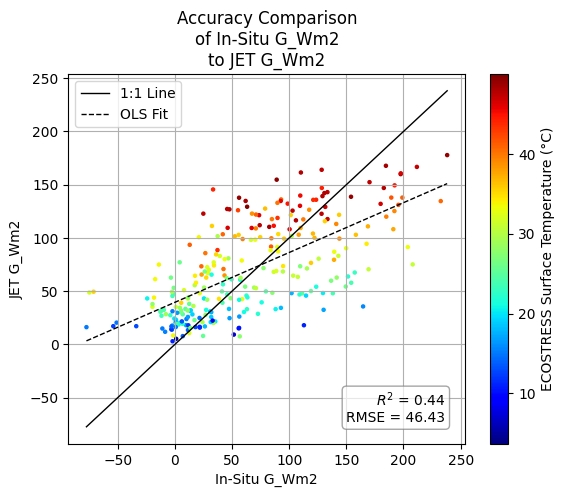

analyzing JET accuracy for H_Wm2 compared to insitu_H_Wm2


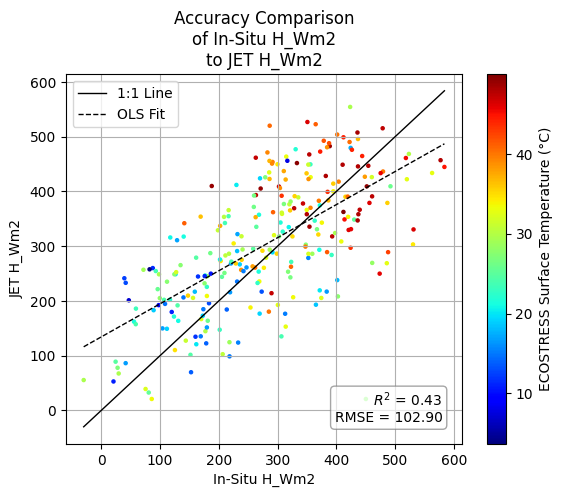

analyzing JET accuracy for LE_Wm2 compared to insitu_LE_Wm2


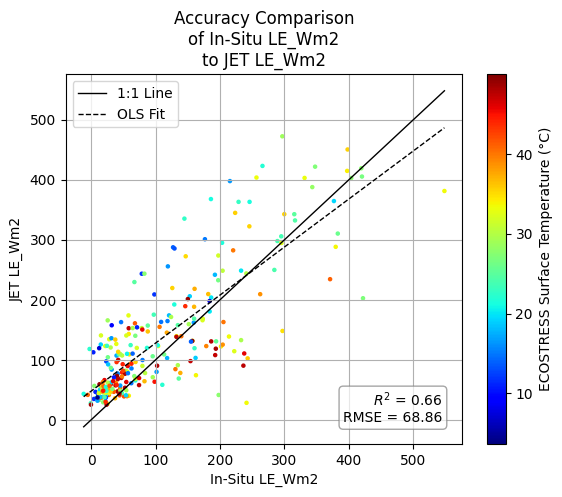

analyzing JET accuracy for LE_daylight_Wm2 compared to insitu_LE_daylight_Wm2
Error processing LE_daylight_Wm2: "['LE_daylight_Wm2'] not in index"
analyzing JET accuracy for RH compared to insitu_RH


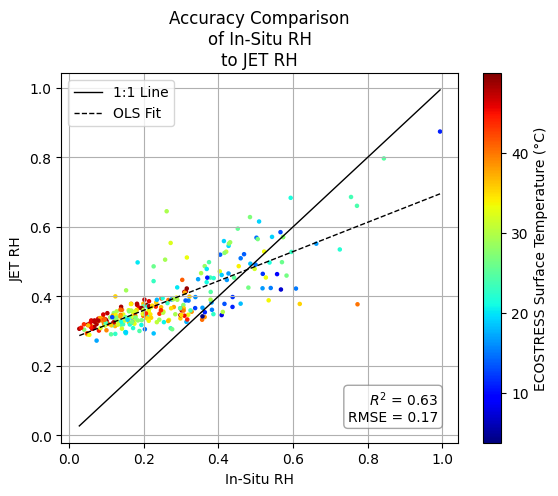

analyzing JET accuracy for Rn_Wm2 compared to insitu_Rn_Wm2


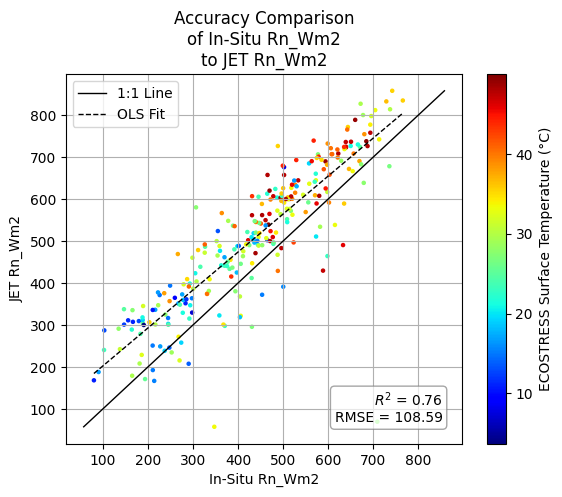

analyzing JET accuracy for Rn_daylight_Wm2 compared to insitu_Rn_daylight_Wm2
Error processing Rn_daylight_Wm2: "['Rn_daylight_Wm2'] not in index"
analyzing JET accuracy for SWin_Wm2 compared to insitu_SWin_Wm2


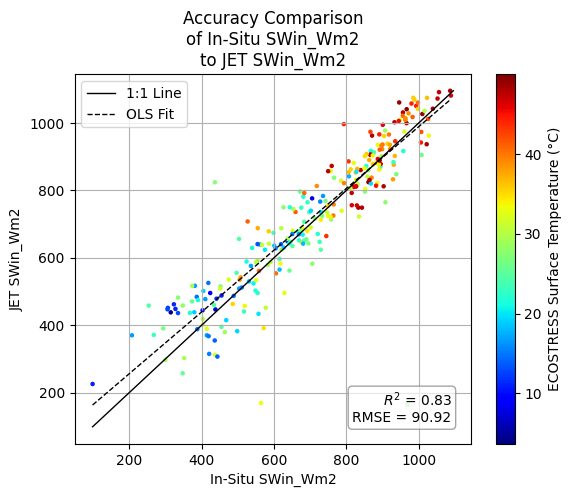

analyzing JET accuracy for Ta_C compared to insitu_Ta_C


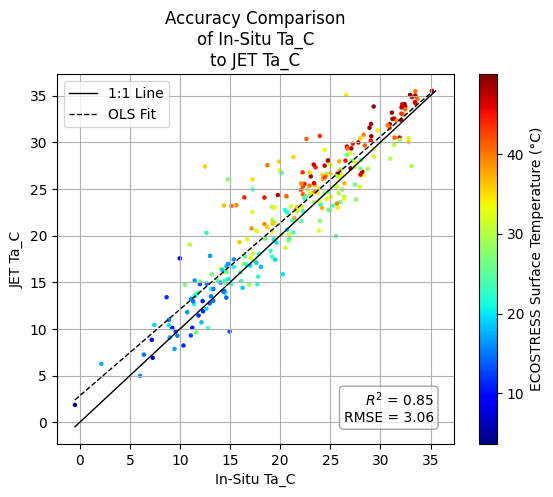

In [10]:
insitu_columns = sorted([column for column in processed.columns if "insitu" in column])

for insitu_variable in insitu_columns:
    output_variable = insitu_variable.replace("insitu_", "")
    print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
    
    try:
        generate_accuracy_plot(
            df=processed,
            x_variable=insitu_variable,
            y_variable=output_variable,
            output_variable=output_variable,
            model_name=model_name,
            save_plots=SAVE_PLOTS
        )
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

# Accuracy Comparison for Net Radiation between BESS and Verma

analyzing JET accuracy for Rn_BESS_Wm2 compared to insitu_Rn_Wm2


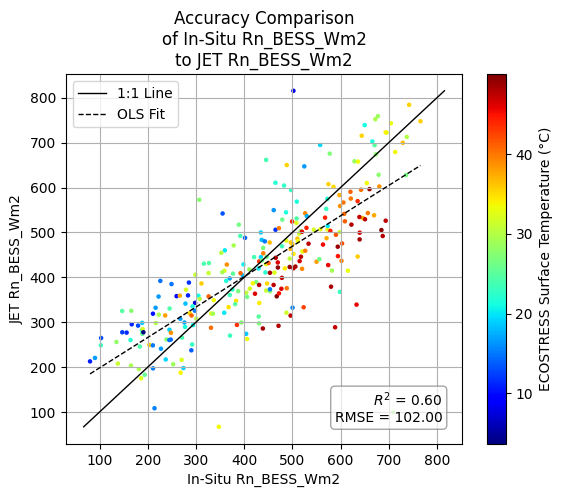

analyzing JET accuracy for Rn_verma_Wm2 compared to insitu_Rn_Wm2


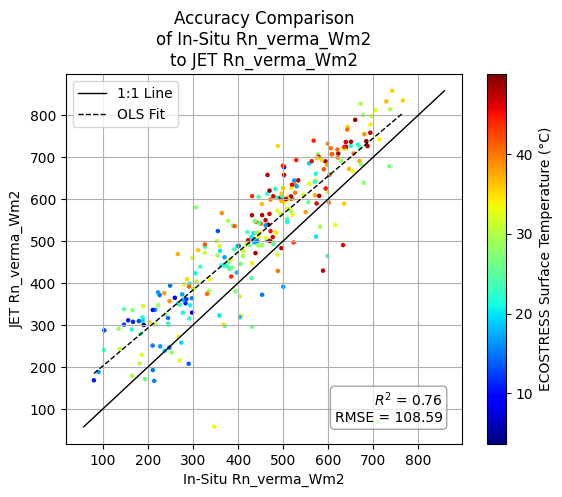

In [11]:
insitu_variable = "insitu_Rn_Wm2"

for output_variable in ["Rn_BESS_Wm2", "Rn_verma_Wm2"]:
    print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
    
    try:
        generate_accuracy_plot(
            df=processed,
            x_variable=insitu_variable,
            y_variable=output_variable,
            output_variable=output_variable,
            model_name=model_name,
            save_plots=SAVE_PLOTS
        )
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

analyzing JET accuracy for LE_BESS_Wm2 compared to insitu_LE_Wm2


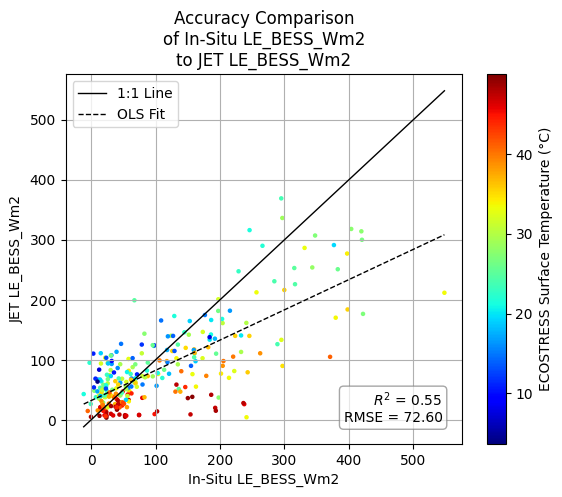

analyzing JET accuracy for LE_STIC_Wm2 compared to insitu_LE_Wm2


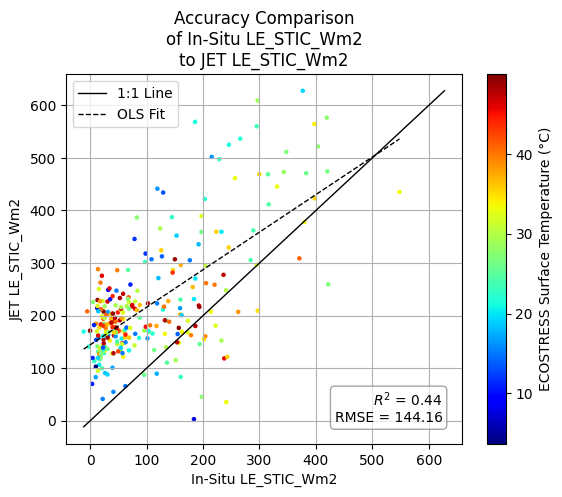

analyzing JET accuracy for LE_PTJPLSM_Wm2 compared to insitu_LE_Wm2


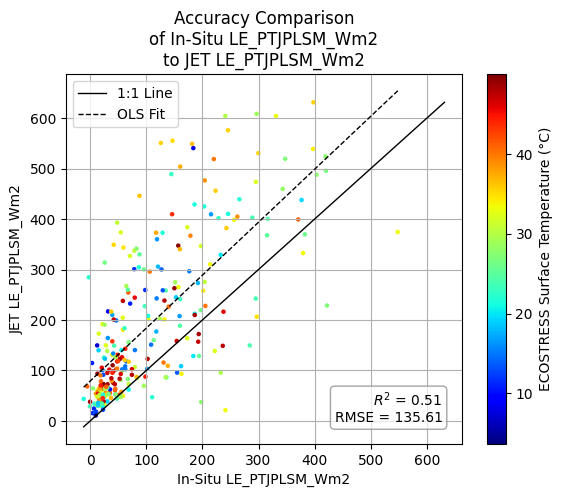

analyzing JET accuracy for LE_PMJPL_Wm2 compared to insitu_LE_Wm2


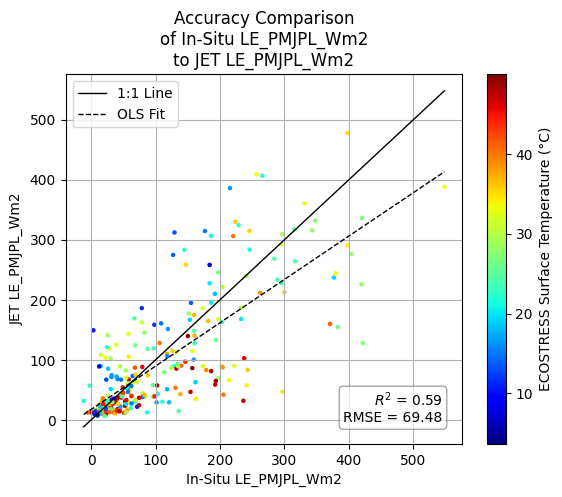

analyzing JET accuracy for LE_Wm2 compared to insitu_LE_Wm2


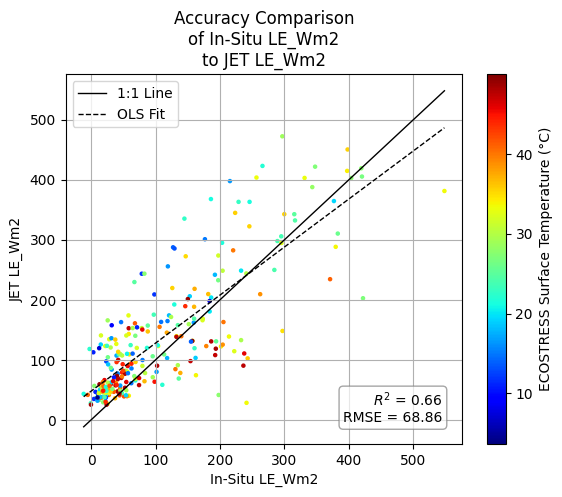

In [12]:
insitu_variable = "insitu_LE_Wm2"

output_variables = [
    "LE_BESS_Wm2",
    "LE_STIC_Wm2",
    "LE_PTJPLSM_Wm2",
    "LE_PMJPL_Wm2",
    "LE_Wm2"
]

for output_variable in output_variables:
    print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
    
    try:
        generate_accuracy_plot(
            df=processed,
            x_variable=insitu_variable,
            y_variable=output_variable,
            output_variable=output_variable,
            model_name=model_name,
            save_plots=SAVE_PLOTS
        )
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

In [13]:
import os
import contextlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol

def SOBOL_sensitivity_analysis(input_df, input_variables, target_output, forward_process, N=256, theme_name="whitegrid", palette_name="viridis"):
    """
    Generates Saltelli samples from the bounds of the input table, runs the 
    forward model via a callback parameter (with console output suppressed), 
    and computes/plots first-order (S1) and total-order (ST) Sobol indices.
    The plot is sorted in descending order by the total-order index (ST).
    """
    # 1. Clean the input table and dynamically define problem bounds
    input_df_clean = input_df.dropna(subset=[var for var in input_variables if var in input_df.columns])
    
    problem = {
        'num_vars': len(input_variables),
        'names': input_variables,
        'bounds': [
            [input_df_clean[var].min(), input_df_clean[var].max()] 
            for var in input_variables
        ]
    }
    
    # 2. Generate Saltelli samples 
    # Note: N should ideally be a power of 2. The total number of samples will be N * (2D + 2)
    param_values = saltelli.sample(problem, N, calc_second_order=True)
    
    # 3. Broadcast a static base row to match the Saltelli matrix size
    # This ensures any required columns NOT in input_variables still exist for the forward_process
    base_row = input_df_clean.iloc[[0]].copy()
    samples_df = pd.concat([base_row] * len(param_values), ignore_index=True)
    
    # Overwrite the input variables with the generated samples
    for i, var in enumerate(input_variables):
        samples_df[var] = param_values[:, i]
        
    # 4. Execute the forward run and suppress its console output
    print(f"Executing forward process for {len(samples_df)} generated samples (console output hidden)...")
    
    with open(os.devnull, 'w') as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            processed_samples = forward_process(samples_df)
            
    print("Forward process complete.")
    
    # 5. Extract the target output values and check for NaNs
    Y = processed_samples[target_output].values
    if np.isnan(Y).any():
        print("Warning: The forward process returned NaN values. Forward-filling to prevent SALib crash.")
        Y = pd.Series(Y).ffill().bfill().values
    
    # 6. Calculate Sobol indices
    Si = sobol.analyze(problem, Y, calc_second_order=True)
    
    # --- Sort the variables based on ST descending ---
    sort_indices = np.argsort(Si['ST'])[::-1]
    sorted_vars = [input_variables[i] for i in sort_indices]
    sorted_S1 = Si['S1'][sort_indices]
    sorted_ST = Si['ST'][sort_indices]
    
    # 7. Visualize First-Order and Total-Order Indices
    sns.set_theme(style=theme_name)
    colors = sns.color_palette(palette_name)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    x = np.arange(len(sorted_vars))
    width = 0.35
    
    ax.bar(x - width/2, sorted_S1, width, label='S1 (First-order: Direct Variance)', color=colors[0], edgecolor="white", linewidth=1)
    ax.bar(x + width/2, sorted_ST, width, label='ST (Total-order: Includes Interactions)', color=colors[1], edgecolor="white", linewidth=1)
    
    ax.set_ylabel('Sobol Index', fontsize=12, weight='bold')
    ax.set_title(f'Sobol Sensitivity Indices for {target_output}', fontsize=15, weight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_vars, rotation=45, ha='right', fontsize=11)
    ax.legend(frameon=True, facecolor='white', edgecolor='lightgray')
    
    # Remove top and right borders for a cleaner look
    sns.despine(left=True)
    ax.grid(axis='y', linestyle='-', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return Si

In [20]:
import os
import contextlib
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol

def SOBOL_scatter_analysis(input_df, input_variables, target_output, forward_process, N=256, theme_name="whitegrid"):
    """
    Generates Saltelli samples, runs the forward model, and computes Sobol indices.
    Instead of bar charts, it outputs a grid of absolute main effect scatter plots 
    with LOWESS trendlines to visualize linearity, sensitivity magnitude, and interactions.
    """
    # 1. Clean the input table and dynamically define problem bounds
    input_df_clean = input_df.dropna(subset=[var for var in input_variables if var in input_df.columns])
    
    problem = {
        'num_vars': len(input_variables),
        'names': input_variables,
        'bounds': [
            [input_df_clean[var].min(), input_df_clean[var].max()] 
            for var in input_variables
        ]
    }
    
    # 2. Generate Saltelli samples 
    param_values = saltelli.sample(problem, N, calc_second_order=True)
    
    # 3. Broadcast a static base row to match the Saltelli matrix size
    base_row = input_df_clean.iloc[[0]].copy()
    samples_df = pd.concat([base_row] * len(param_values), ignore_index=True)
    
    # Overwrite the input variables with the generated samples
    for i, var in enumerate(input_variables):
        samples_df[var] = param_values[:, i]
        
    # 4. Execute the forward run and suppress its console output
    print(f"Executing forward process for {len(samples_df)} generated samples (console output hidden)...")
    
    with open(os.devnull, 'w') as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            processed_samples = forward_process(samples_df)
            
    print("Forward process complete.")
    
    # 5. Extract the target output values and check for NaNs
    Y = processed_samples[target_output].values
    if np.isnan(Y).any():
        print("Warning: The forward process returned NaN values. Forward-filling to prevent SALib crash.")
        Y = pd.Series(Y).ffill().bfill().values
    
    # 6. Calculate Sobol indices (kept so you can still return the raw numbers)
    Si = sobol.analyze(problem, Y, calc_second_order=True)
    
    # 7. Visualize Absolute Main Effect Scatter Plots
    print("Generating main effect scatter plots...")
    sns.set_theme(style=theme_name)
    
    # Build a DataFrame specifically for plotting
    plot_df = pd.DataFrame(param_values, columns=input_variables)
    plot_df[target_output] = Y
    
    # Determine a clean grid layout based on the number of variables (max 3 columns)
    num_vars = len(input_variables)
    cols = min(3, num_vars)
    rows = math.ceil(num_vars / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    
    # Ensure axes is always a flat array for easy iteration, even if it's 1x1
    axes = np.atleast_1d(axes).flatten()
    
    for i, var in enumerate(input_variables):
        # Scatter plot with LOWESS trendline representing conditional expectation
        sns.regplot(
            data=plot_df, 
            x=var, 
            y=target_output, 
            ax=axes[i], 
            scatter_kws={
                'alpha': 0.2,       # Transparency to show density/interactions
                's': 8,             # Smaller dot size for thick clouds
                'edgecolor': 'none' # Removes borders from dots for a cleaner cloud
            }, 
            line_kws={
                'color': 'red',     # Make the trendline stand out
                'linewidth': 2.5
            },
            lowess=True             # Requires 'statsmodels' library
        )
        
        # Formatting to match the cleaner look of your Monte Carlo plots
        axes[i].set_title(f'{var} vs {target_output}', weight='bold')
        axes[i].set_ylabel(f'Absolute {target_output}')
        axes[i].set_xlabel(f'Sampled {var}')
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
    # Hide any unused subplots in the grid if num_vars isn't a perfect multiple of cols
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()
    
    return Si

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 2560 generated samples (console output hidden)...
[2026-08-11 11:32:04 INFO] starting JET table processing
[2026-08-11 11:32:04 INFO] started extracting geometry from JET input table
[2026-08-11 11:32:04 INFO] completed extracting geometry from JET input table (0.023 seconds)
[2026-08-11 11:32:04 INFO] started extracting time from JET input table
[2026-08-11 11:32:04 INFO] completed extracting time from JET input table (0.004 seconds)
[2026-08-11 11:32:04 INFO] running Forest Light Environmental Simulator
[2026-08-11 11:32:04 INFO] completed processing FLiES-ANN in 0.23 seconds
[2026-08-11 11:32:04 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-11 11:32:04 INFO] * 0.021219292649443: 2560
[2026-08-11 11:32:04 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-11 11:32:04 INFO] * 0.1110699046857625: 2560
[2026-08-11 11:32:04 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

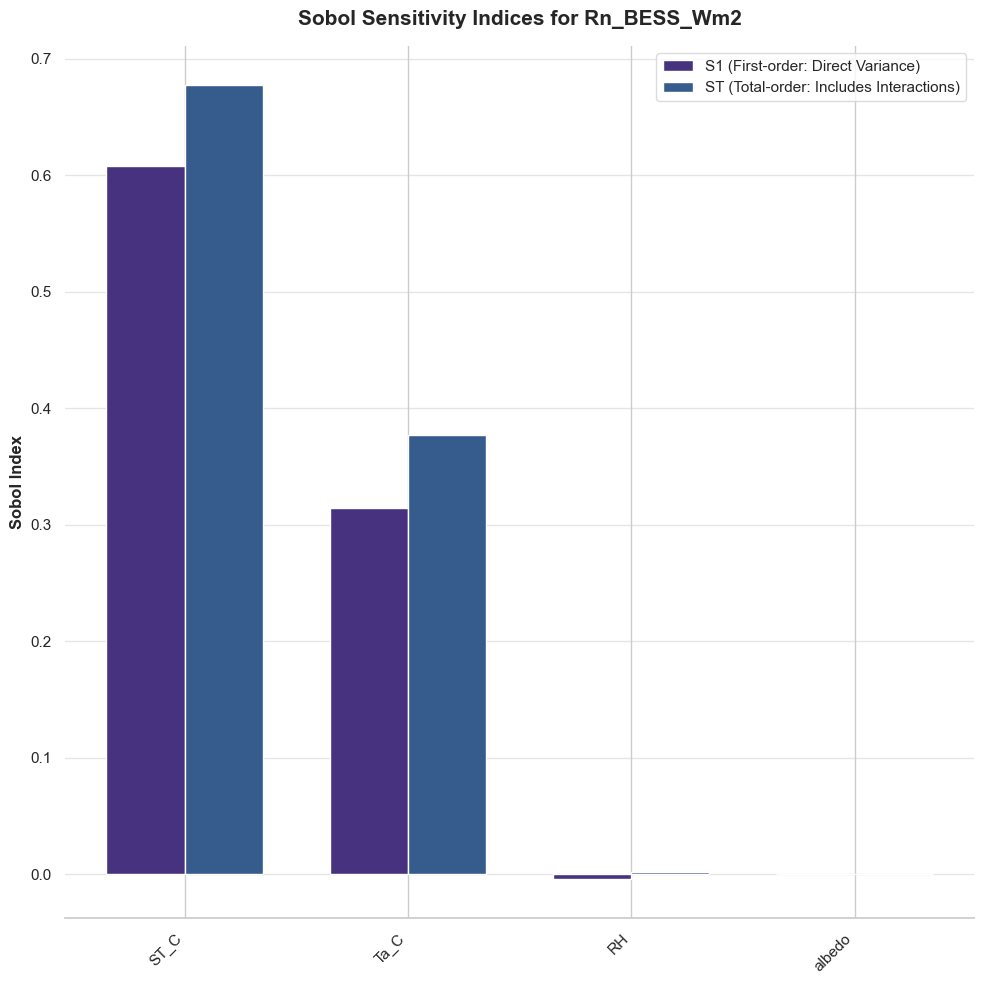

In [25]:
target_output = "Rn_BESS_Wm2"

input_variables = [
    "ST_C", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1850714436.py:30: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 2560 generated samples (console output hidden)...
[2026-08-11 11:35:16 INFO] starting JET table processing
[2026-08-11 11:35:16 INFO] started extracting geometry from JET input table
[2026-08-11 11:35:16 INFO] completed extracting geometry from JET input table (0.022 seconds)
[2026-08-11 11:35:16 INFO] started extracting time from JET input table
[2026-08-11 11:35:16 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-11 11:35:16 INFO] running Forest Light Environmental Simulator
[2026-08-11 11:35:16 INFO] completed processing FLiES-ANN in 0.20 seconds
[2026-08-11 11:35:16 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-11 11:35:16 INFO] * 0.021219292649443: 2560
[2026-08-11 11:35:16 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-11 11:35:16 INFO] * 0.1110699046857625: 2560
[2026-08-11 11:35:16 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

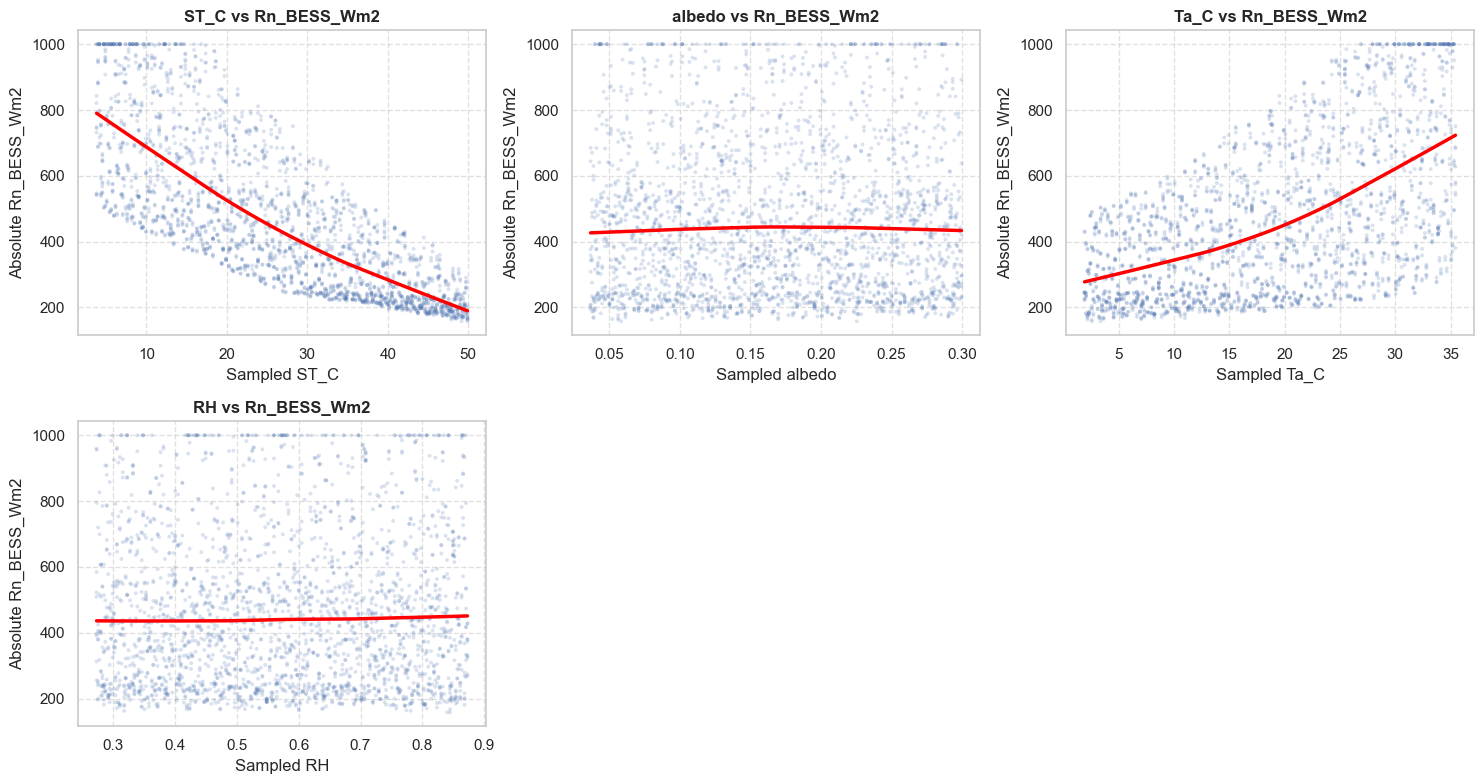

In [26]:
target_output = "Rn_BESS_Wm2"

input_variables = [
    "ST_C", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_scatter_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 2560 generated samples (console output hidden)...
[2026-08-11 11:36:01 INFO] starting JET table processing
[2026-08-11 11:36:01 INFO] started extracting geometry from JET input table
[2026-08-11 11:36:01 INFO] completed extracting geometry from JET input table (0.023 seconds)
[2026-08-11 11:36:01 INFO] started extracting time from JET input table
[2026-08-11 11:36:01 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-11 11:36:01 INFO] running Forest Light Environmental Simulator
[2026-08-11 11:36:01 INFO] completed processing FLiES-ANN in 0.20 seconds
[2026-08-11 11:36:01 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-11 11:36:01 INFO] * 0.021219292649443: 2560
[2026-08-11 11:36:01 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-11 11:36:01 INFO] * 0.1110699046857625: 2560
[2026-08-11 11:36:01 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

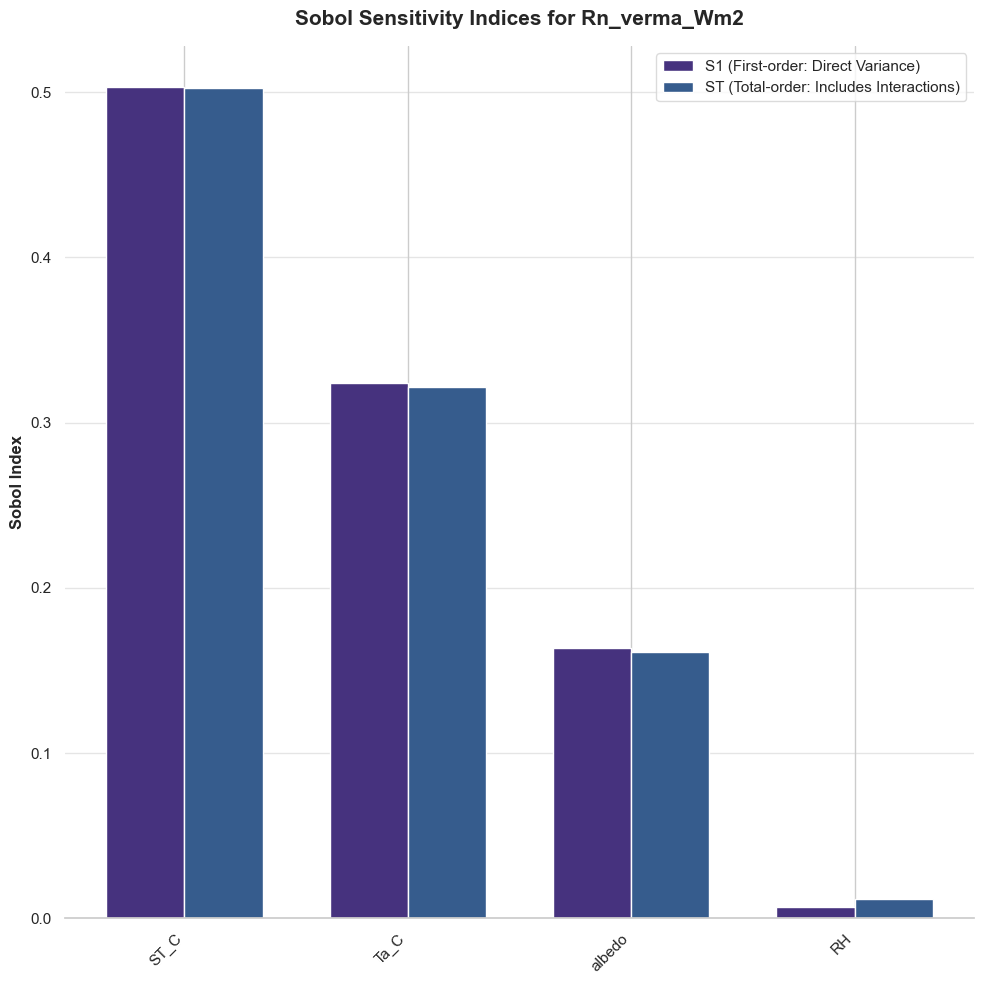

In [27]:
target_output = "Rn_verma_Wm2"

input_variables = [
    "ST_C", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1850714436.py:30: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 2560 generated samples (console output hidden)...
[2026-08-11 11:37:14 INFO] starting JET table processing
[2026-08-11 11:37:14 INFO] started extracting geometry from JET input table
[2026-08-11 11:37:14 INFO] completed extracting geometry from JET input table (0.022 seconds)
[2026-08-11 11:37:14 INFO] started extracting time from JET input table
[2026-08-11 11:37:14 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-11 11:37:14 INFO] running Forest Light Environmental Simulator
[2026-08-11 11:37:14 INFO] completed processing FLiES-ANN in 0.21 seconds
[2026-08-11 11:37:14 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-11 11:37:14 INFO] * 0.021219292649443: 2560
[2026-08-11 11:37:14 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-11 11:37:14 INFO] * 0.1110699046857625: 2560
[2026-08-11 11:37:14 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

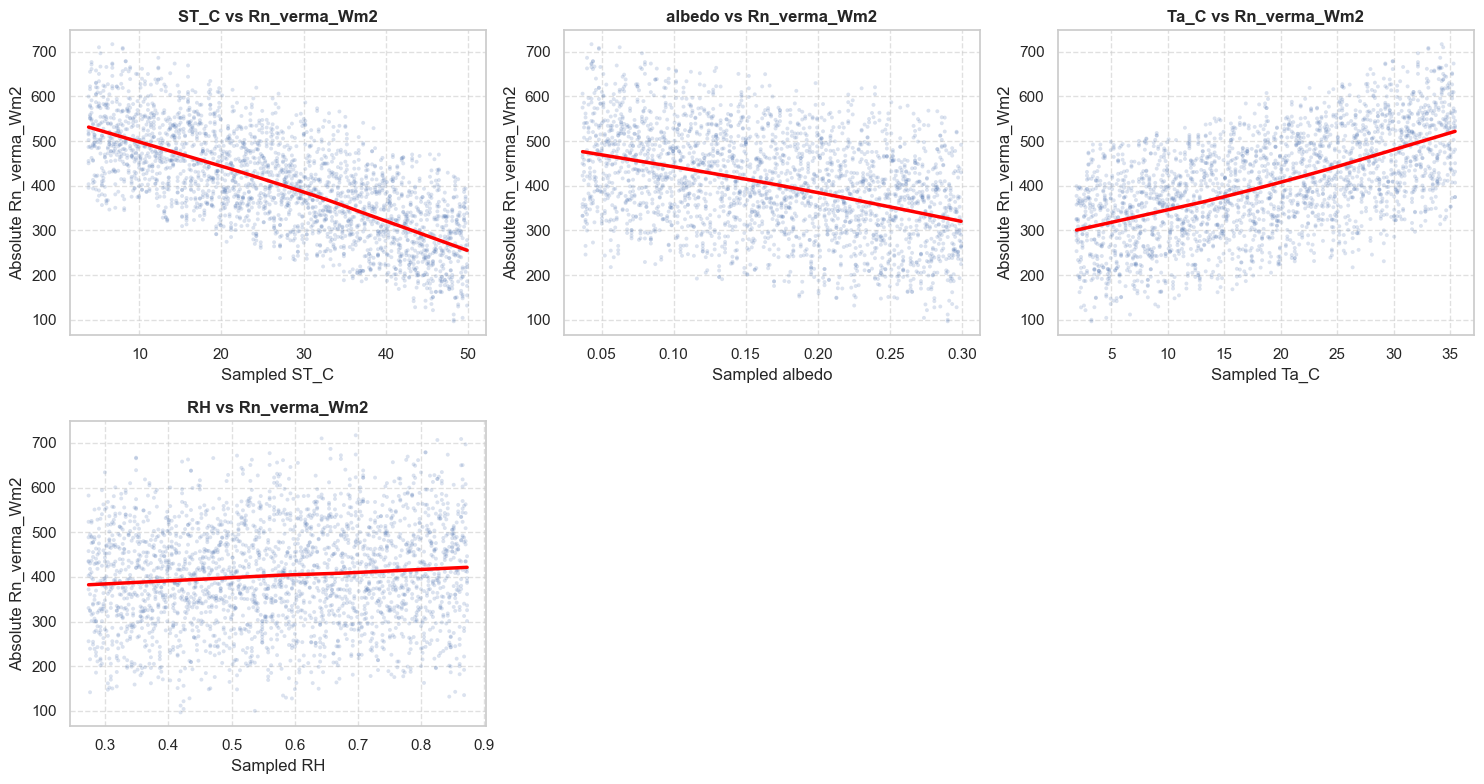

In [29]:
target_output = "Rn_verma_Wm2"

input_variables = [
    "ST_C", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_scatter_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 3072 generated samples (console output hidden)...
[2026-08-09 19:47:20 INFO] starting JET table processing
[2026-08-09 19:47:20 INFO] started extracting geometry from JET input table
[2026-08-09 19:47:20 INFO] completed extracting geometry from JET input table (0.028 seconds)
[2026-08-09 19:47:20 INFO] started extracting time from JET input table
[2026-08-09 19:47:21 INFO] completed extracting time from JET input table (0.004 seconds)
[2026-08-09 19:47:21 INFO] running Forest Light Environmental Simulator
[2026-08-09 19:47:21 INFO] completed processing FLiES-ANN in 0.36 seconds
[2026-08-09 19:47:21 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-09 19:47:21 INFO] * 0.021219292649443: 3072
[2026-08-09 19:47:21 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-09 19:47:21 INFO] * 0.1110699046857625: 3072
[2026-08-09 19:47:21 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

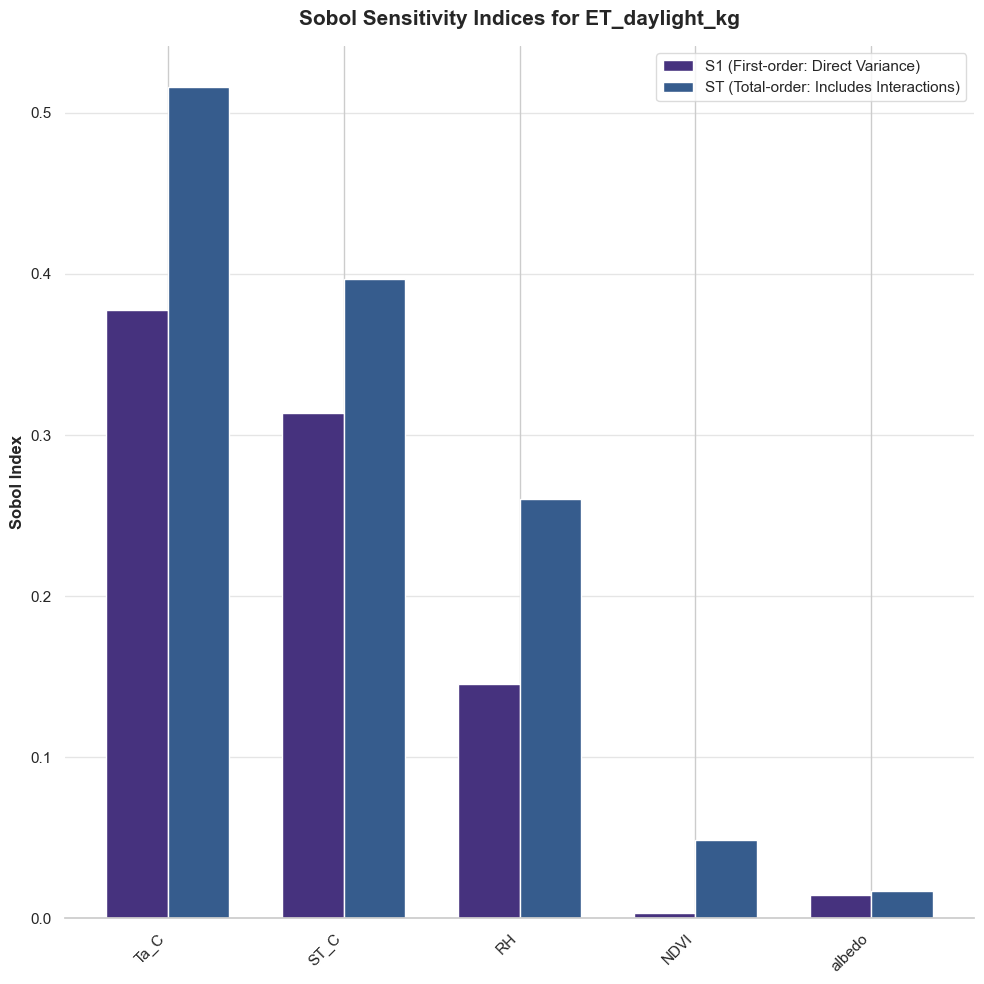

In [14]:
target_output = "ET_daylight_kg"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1850714436.py:30: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 3072 generated samples (console output hidden)...
[2026-08-10 10:44:43 INFO] starting JET table processing
[2026-08-10 10:44:43 INFO] started extracting geometry from JET input table
[2026-08-10 10:44:43 INFO] completed extracting geometry from JET input table (0.026 seconds)
[2026-08-10 10:44:43 INFO] started extracting time from JET input table
[2026-08-10 10:44:43 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-10 10:44:43 INFO] running Forest Light Environmental Simulator
[2026-08-10 10:44:43 INFO] completed processing FLiES-ANN in 0.22 seconds
[2026-08-10 10:44:43 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-10 10:44:43 INFO] * 0.021219292649443: 3072
[2026-08-10 10:44:43 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-10 10:44:43 INFO] * 0.1110699046857625: 3072
[2026-08-10 10:44:43 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

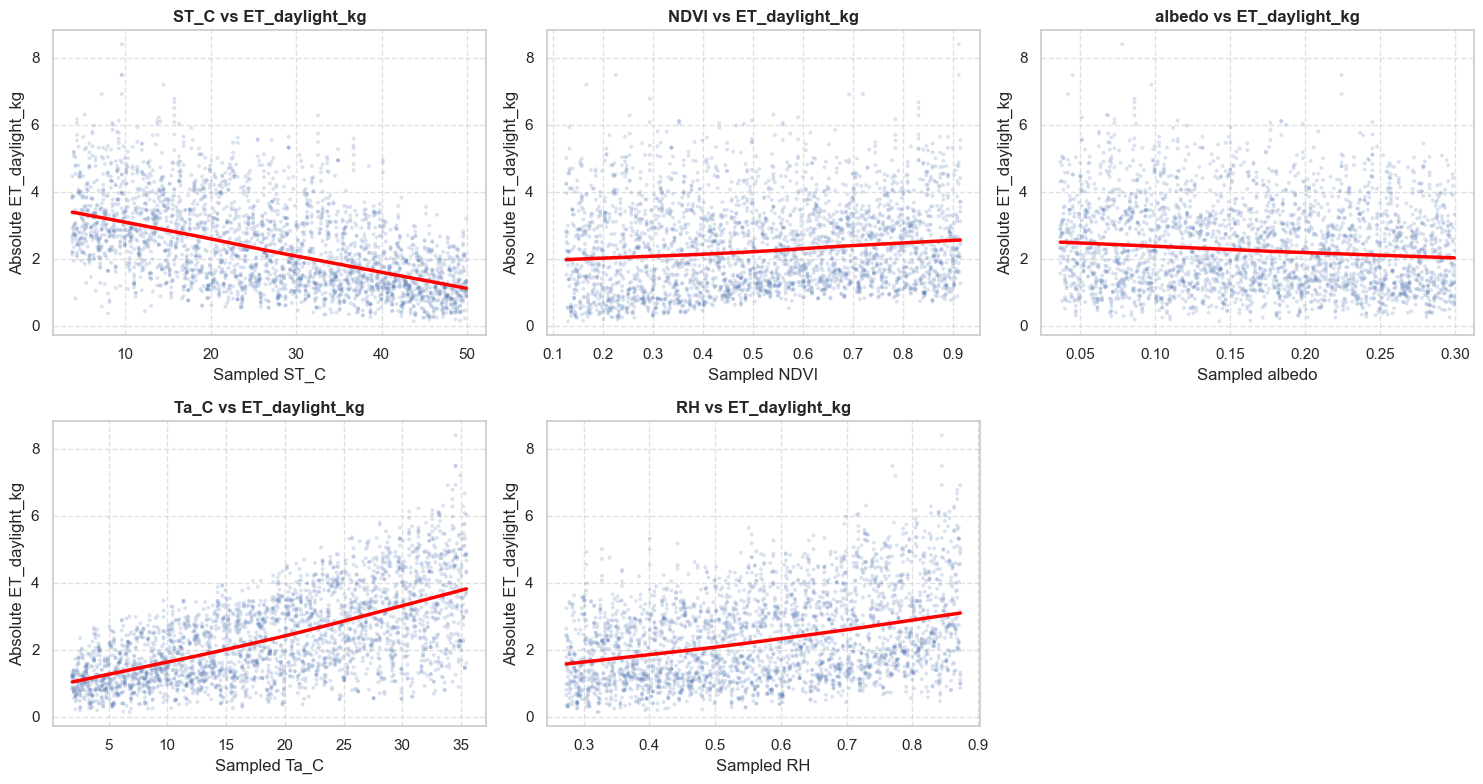

In [23]:
target_output = "ET_daylight_kg"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_scatter_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 3072 generated samples (console output hidden)...
[2026-08-09 19:47:22 INFO] starting JET table processing
[2026-08-09 19:47:22 INFO] started extracting geometry from JET input table
[2026-08-09 19:47:22 INFO] completed extracting geometry from JET input table (0.027 seconds)
[2026-08-09 19:47:22 INFO] started extracting time from JET input table
[2026-08-09 19:47:22 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-09 19:47:22 INFO] running Forest Light Environmental Simulator
[2026-08-09 19:47:23 INFO] completed processing FLiES-ANN in 0.23 seconds
[2026-08-09 19:47:23 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-09 19:47:23 INFO] * 0.021219292649443: 3072
[2026-08-09 19:47:23 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-09 19:47:23 INFO] * 0.1110699046857625: 3072
[2026-08-09 19:47:23 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

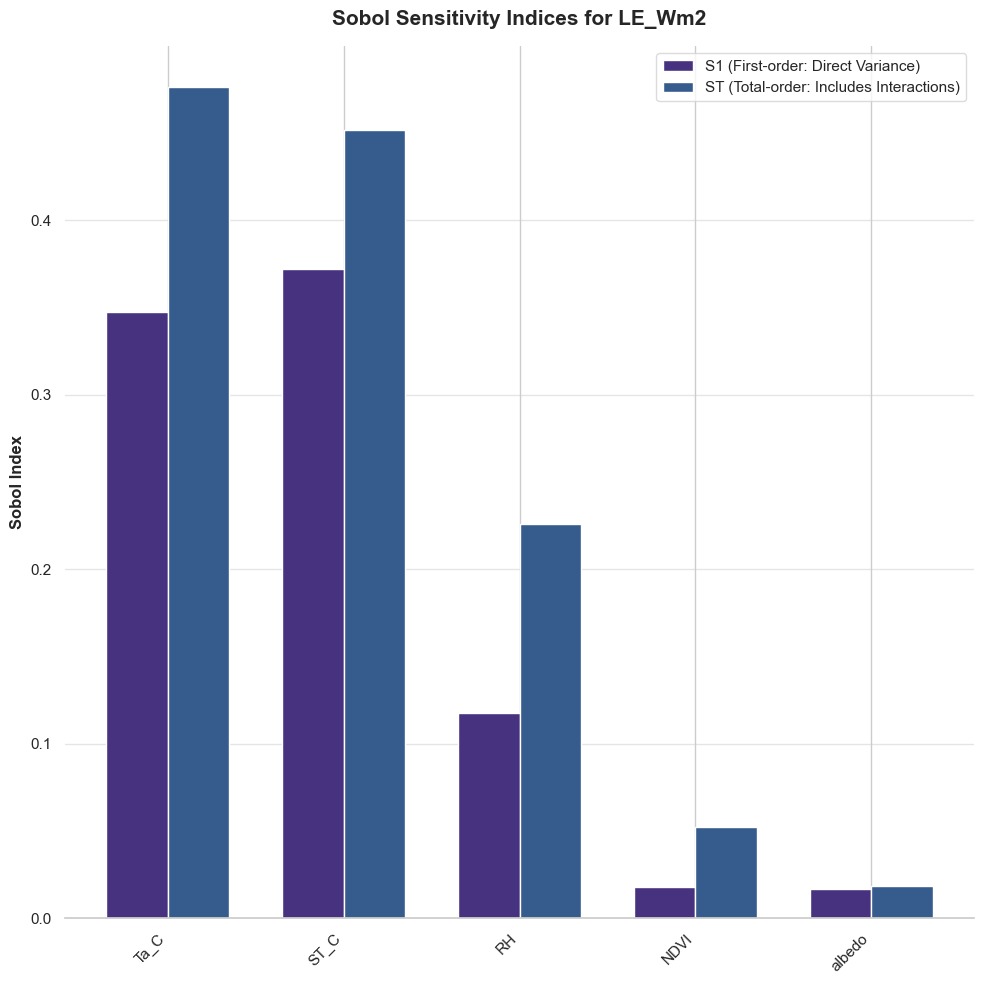

In [15]:
target_output = "LE_Wm2"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 3072 generated samples (console output hidden)...
[2026-08-09 19:47:24 INFO] starting JET table processing
[2026-08-09 19:47:24 INFO] started extracting geometry from JET input table
[2026-08-09 19:47:24 INFO] completed extracting geometry from JET input table (0.026 seconds)
[2026-08-09 19:47:24 INFO] started extracting time from JET input table
[2026-08-09 19:47:24 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-09 19:47:24 INFO] running Forest Light Environmental Simulator
[2026-08-09 19:47:24 INFO] completed processing FLiES-ANN in 0.24 seconds
[2026-08-09 19:47:24 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-09 19:47:24 INFO] * 0.021219292649443: 3072
[2026-08-09 19:47:24 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-09 19:47:24 INFO] * 0.1110699046857625: 3072
[2026-08-09 19:47:24 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

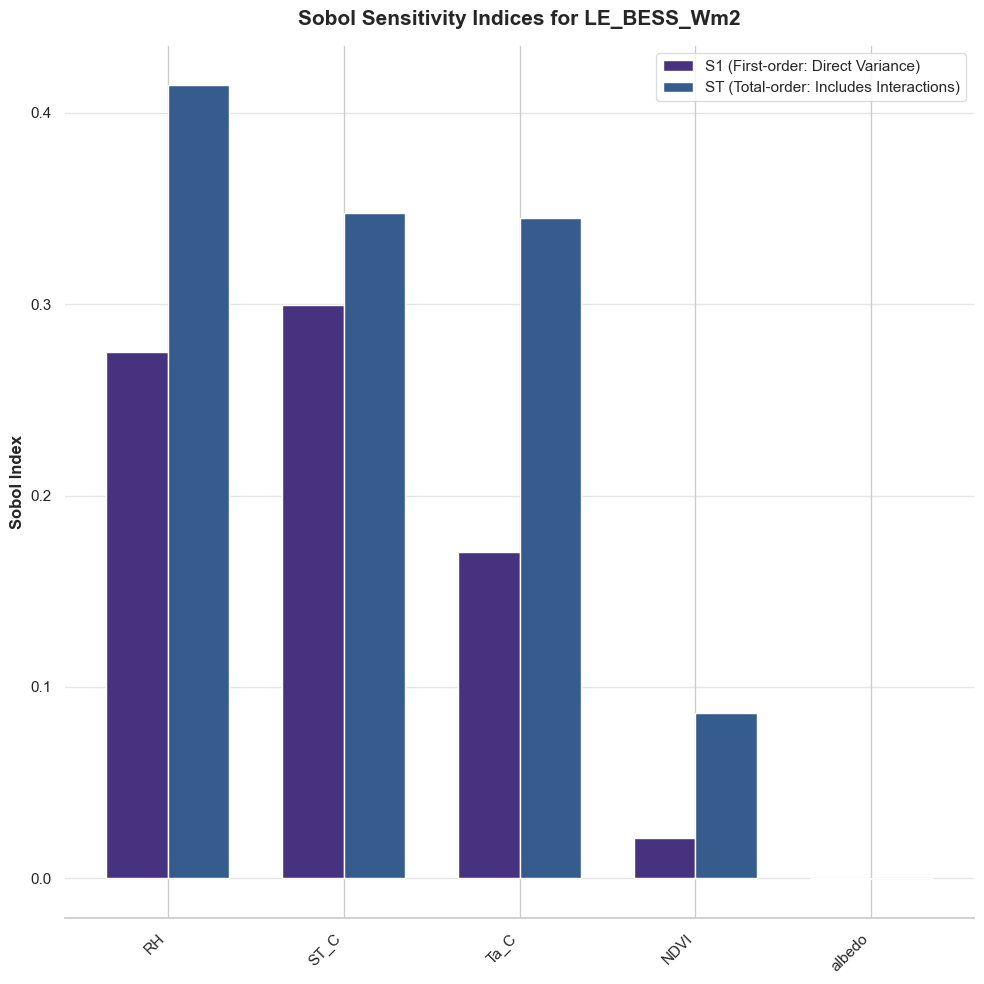

In [16]:
target_output = "LE_BESS_Wm2"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 3072 generated samples (console output hidden)...
[2026-08-09 19:47:26 INFO] starting JET table processing
[2026-08-09 19:47:26 INFO] started extracting geometry from JET input table
[2026-08-09 19:47:26 INFO] completed extracting geometry from JET input table (0.026 seconds)
[2026-08-09 19:47:26 INFO] started extracting time from JET input table
[2026-08-09 19:47:26 INFO] completed extracting time from JET input table (0.003 seconds)
[2026-08-09 19:47:26 INFO] running Forest Light Environmental Simulator
[2026-08-09 19:47:26 INFO] completed processing FLiES-ANN in 0.24 seconds
[2026-08-09 19:47:26 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-09 19:47:26 INFO] * 0.021219292649443: 3072
[2026-08-09 19:47:26 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-09 19:47:26 INFO] * 0.1110699046857625: 3072
[2026-08-09 19:47:26 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

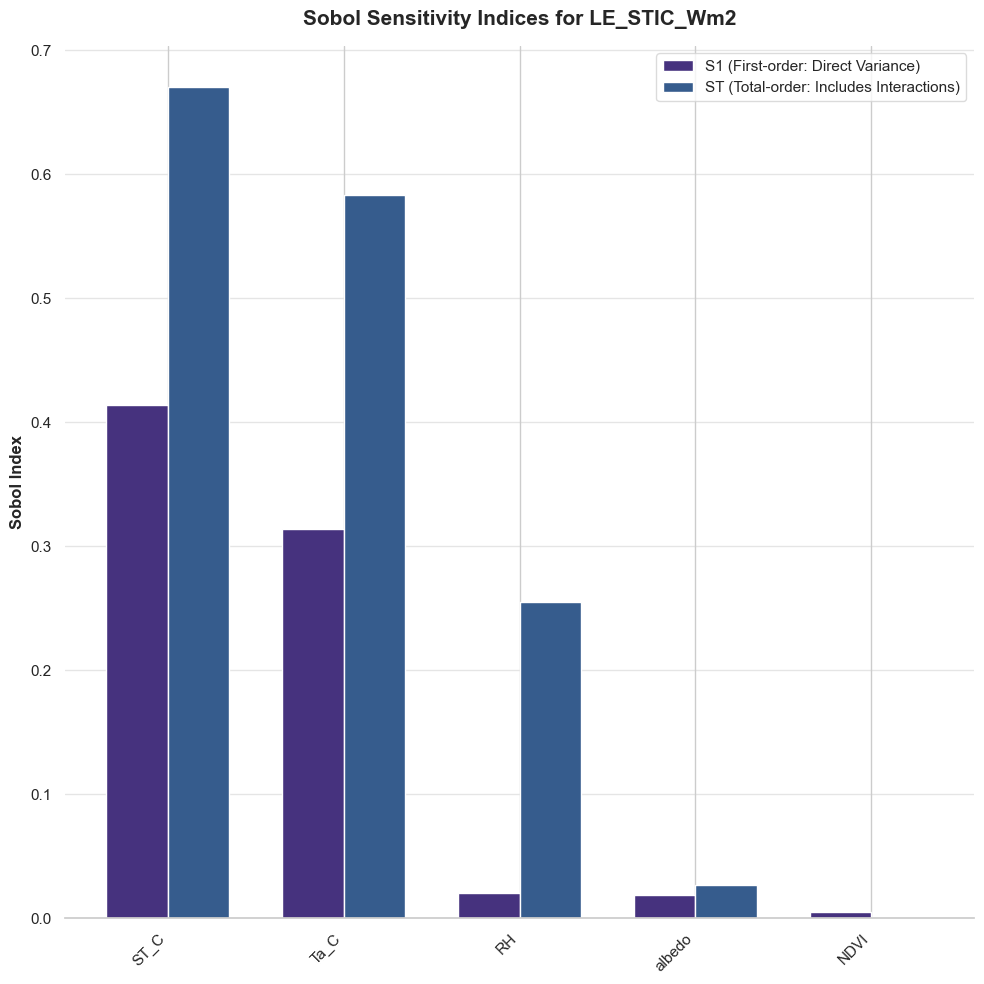

In [17]:
target_output = "LE_STIC_Wm2"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 3072 generated samples (console output hidden)...
[2026-08-09 19:47:28 INFO] starting JET table processing
[2026-08-09 19:47:28 INFO] started extracting geometry from JET input table
[2026-08-09 19:47:28 INFO] completed extracting geometry from JET input table (0.027 seconds)
[2026-08-09 19:47:28 INFO] started extracting time from JET input table
[2026-08-09 19:47:28 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-09 19:47:28 INFO] running Forest Light Environmental Simulator
[2026-08-09 19:47:28 INFO] completed processing FLiES-ANN in 0.23 seconds
[2026-08-09 19:47:28 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-09 19:47:28 INFO] * 0.021219292649443: 3072
[2026-08-09 19:47:28 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-09 19:47:28 INFO] * 0.1110699046857625: 3072
[2026-08-09 19:47:28 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

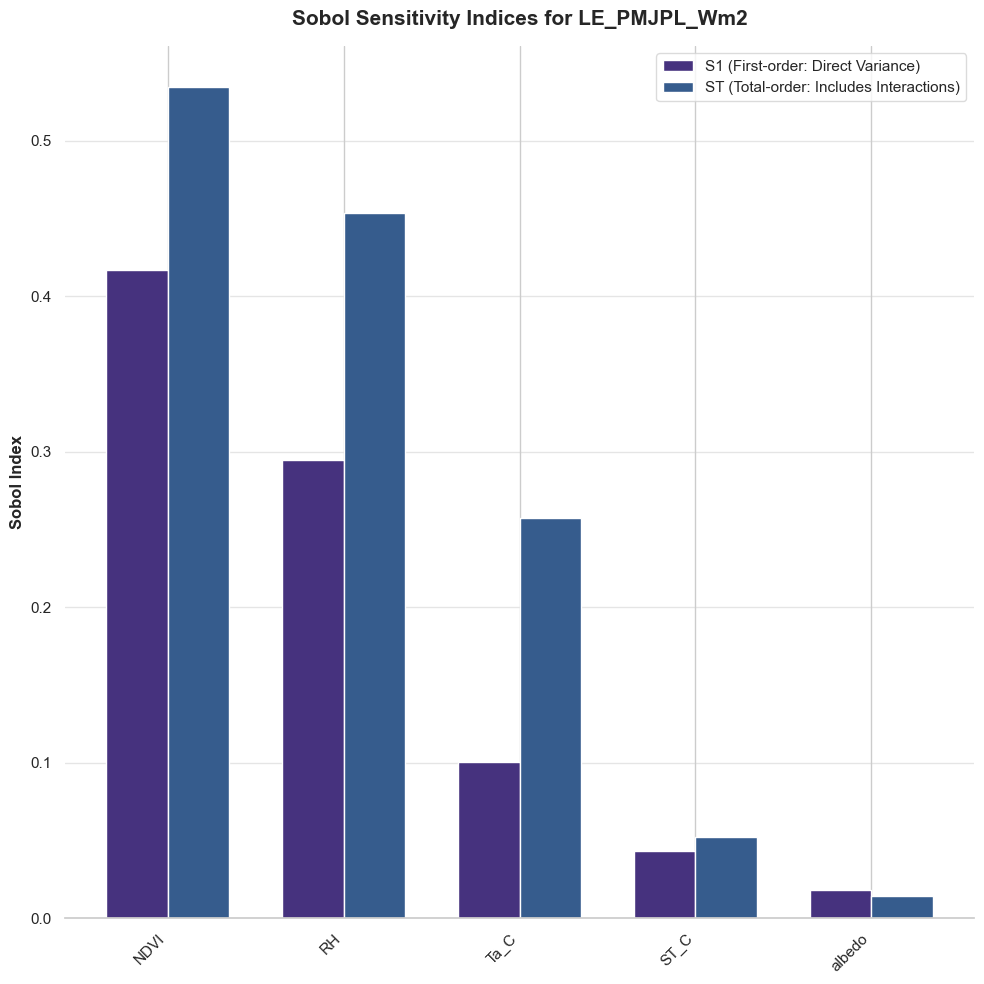

In [18]:
target_output = "LE_PMJPL_Wm2"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_5769/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 3072 generated samples (console output hidden)...
[2026-08-09 19:47:29 INFO] starting JET table processing
[2026-08-09 19:47:29 INFO] started extracting geometry from JET input table
[2026-08-09 19:47:29 INFO] completed extracting geometry from JET input table (0.026 seconds)
[2026-08-09 19:47:29 INFO] started extracting time from JET input table
[2026-08-09 19:47:29 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-09 19:47:29 INFO] running Forest Light Environmental Simulator
[2026-08-09 19:47:30 INFO] completed processing FLiES-ANN in 0.25 seconds
[2026-08-09 19:47:30 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-09 19:47:30 INFO] * 0.021219292649443: 3072
[2026-08-09 19:47:30 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-09 19:47:30 INFO] * 0.1110699046857625: 3072
[2026-08-09 19:47:30 INFO] variable PAR_direct_Wm2 min: 237.841 mean: 238.051 max: 238.555 nan: 0.00%

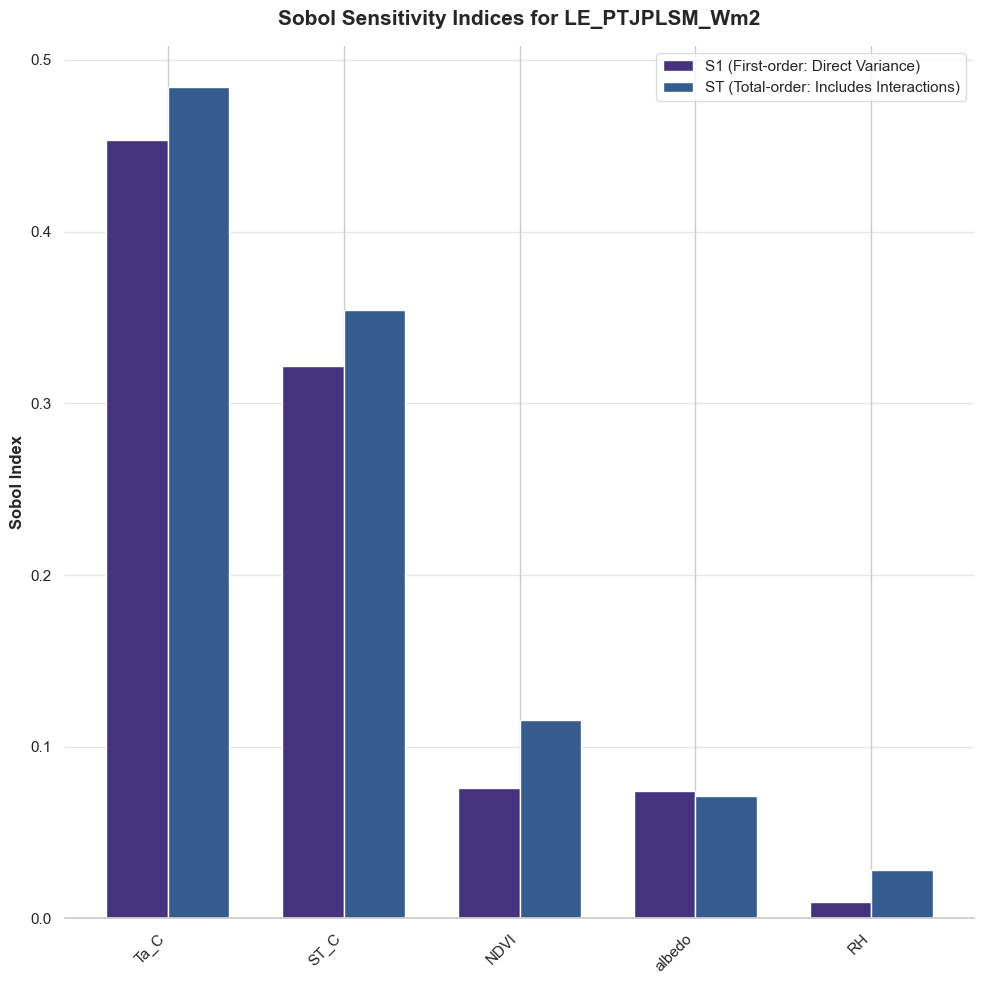

In [19]:
target_output = "LE_PTJPLSM_Wm2"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)